Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.cluster import KMeans

Data Collection and Analysis

In [2]:
# loading the data from csv file to a Pandas DataFrame
customer_data = pd.read_csv('../data/Mall_Customers.csv')

In [3]:
# first 5 rows of the datafframe
customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# finding the no. of rows and columns 
customer_data.shape

(200, 5)

In [5]:
#getting some information about the dataset
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
# checking missing values 
customer_data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

choosing the annual income column & spending Score column 

In [7]:
X = customer_data.iloc[:,[3,4]].values

Feature Scaling 

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [9]:
print(X_scaled)

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]
 [-1.66266033  1.00159627]
 [-1.62449091 -1.71591298]
 [-1.62449091  1.70038436]
 [-1.58632148 -1.83237767]
 [-1.58632148  0.84631002]
 [-1.58632148 -1.4053405 ]
 [-1.58632148  1.89449216]
 [-1.54815205 -1.36651894]
 [-1.54815205  1.04041783]
 [-1.54815205 -1.44416206]
 [-1.54815205  1.11806095]
 [-1.50998262 -0.59008772]
 [-1.50998262  0.61338066]
 [-1.43364376 -0.82301709]
 [-1.43364376  1.8556706 ]
 [-1.39547433 -0.59008772]
 [-1.39547433  0.88513158]
 [-1.3573049  -1.75473454]
 [-1.3573049   0.88513158]
 [-1.24279661 -1.4053405 ]
 [-1.24279661  1.23452563]
 [-1.24279661 -0.7065524 ]
 [-1.24279661  0.41927286]
 [-1.20462718 -0.74537397]
 [-1.20462718  1.42863343]
 [-1.16645776 -1.7935561 ]
 [-1.16645776  0.88513158]
 [-1.05194947 -1.7935561 ]
 [-1.05194947  1.62274124]
 [-1.05194947 -1.4053405 ]
 [-1.05194947  1.19570407]
 [-1.01378004 -1.28887582]
 

Choosing the number of clusters

WCSS -> Within clusters sum of squares (finds the distance between each data points and clusters)

In [10]:
# finding wcss value for different number of clusters

wcss = []  #empty list   
for i in range(1, 11):    #we need 10 clusters
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_) 

Data Visualization

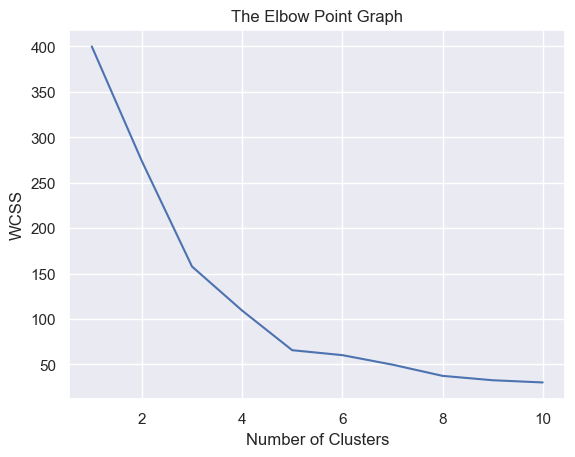

In [11]:
# plot an elbow graph

sns.set()
plt.plot(range(1,11), wcss) 
plt.title('The Elbow Point Graph')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

Choosing Optimal Clusters

Optimum no. of clusters = 5

Training the K-means Clustering Model

In [12]:
kmeans = KMeans(n_clusters=5, init='k-means++',random_state=0)

# return a label for each data point based on their cluster
Y = kmeans.fit_predict(X_scaled)

print(Y)

[3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 0 3 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 0 1 2 1 2 1 0 1 2 1 2 1 2 1 2 1 0 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]


Cluster Visualization 

5 clusters - 0,1,2,3,4

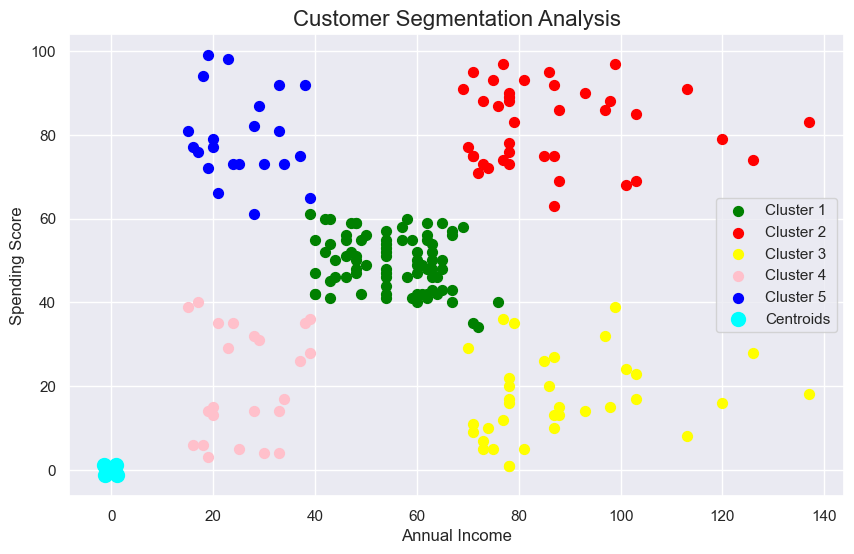

In [13]:
# plotting all the clusters and their centroids

plt.figure(figsize=(10,6))
plt.scatter(X[Y==0,0], X[Y==0,1], s=50, c='green', label='Cluster 1')
plt.scatter(X[Y==1,0], X[Y==1,1], s=50, c='red', label='Cluster 2')
plt.scatter(X[Y==2,0], X[Y==2,1], s=50, c='yellow', label='Cluster 3')
plt.scatter(X[Y==3,0], X[Y==3,1], s=50, c='pink', label='Cluster 4')
plt.scatter(X[Y==4,0], X[Y==4,1], s=50, c='blue', label='Cluster 5')

# plot the centroids 
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c='cyan', label='Centroids')

plt.title('Customer Segmentation Analysis', fontsize=16)
plt.xlabel('Annual Income', fontsize=12)
plt.ylabel('Spending Score', fontsize=12)

plt.legend()
plt.grid(True)

plt.show()

Silhouette Score Analysis 

Silhouette Score was used to evaluate clustering performance. A higher score indicates better separation between customer clusters.

In [14]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, Y)

print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


Business Insight

1. Cluster 1 contains medium-income medium-spending customers.

2. Cluster 2 represents high-income high-spending customers.

3. Cluster 3 includes high-income low-spending customers.

4. Cluster 4 consists of low-income low-spending customers.

5. Cluster 5 contains low-income high-spending customers.

6. Premium marketing campaigns can target Cluster 2.

7. Discount and engagement strategies may improve Cluster 3 spending.

8. Affordable product recommendations can target Clusters 4 and 5.

Conclusion

The K-Means clustering model successfully segmented customers into different groups based on annual income and spending behavior. These insights can help businesses improve customer targeting and marketing strategies.

In [15]:
import pickle

pickle.dump(kmeans, open('kmeans_model.pkl', 'wb'))

In [17]:
model = pickle.load(open('../models/kmeans_model.pkl', 'rb'))

In [18]:
pickle.dump(scaler, open('../models/scaler.pkl', 'wb'))